# 02 — Moving-average crossover with volatility targeting

## Hypothesis

Persistent trends may allow a simple long/flat rule to participate in sustained advances while reducing exposure during prolonged declines. A fast/slow moving-average crossover is a transparent baseline for testing that idea. Volatility targeting is tested as a sizing overlay, not as a separate source of predictive information.

> Educational research only; this is not financial advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Start with the assumptions, then follow the data and rule definitions. The tables and charts report the formal test period. Finish with <strong>What went well / what went wrong</strong> — that is where the research judgment and limitations are made explicit.
</div>


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import (
    moving_average_signal,
    run_backtest,
    split_time_series,
    volatility_target_position,
)
from src.data import load_price_data, make_demo_ohlcv
from src.metrics import calculate_metrics
from src.plots import monthly_returns, plot_drawdown, plot_equity_curve

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📜 Trading rules and assumptions

- Long one unit when the fast SMA is above the slow SMA; otherwise flat.
- Compare fixed 100% exposure with 15% annualized volatility targeting, capped at 100% exposure.
- Calculate indicators from daily closes. Shift the target position by one bar before applying returns.
- Charge 10 bps per unit of absolute exposure change.
- Use the first 60% of observations for parameter research, the next 20% for selection, and the final 20% as an untouched test period.
- Compare all results with buy-and-hold for the same asset and dates.

In [2]:
USE_DEMO_DATA = False
if USE_DEMO_DATA:
    prices = make_demo_ohlcv(periods=2_000, seed=11)
else:
    try:
        prices = load_price_data('SPY', '2010-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({exc}); using deterministic demo data.')
        prices = make_demo_ohlcv(periods=2_000, seed=11)

splits = split_time_series(prices, train_fraction=0.60, validation_fraction=0.20)
print({name: (part.index.min().date(), part.index.max().date(), len(part)) for name, part in splits.items()})

{'train': (datetime.date(2010, 1, 4), datetime.date(2019, 8, 6), 2414), 'validation': (datetime.date(2019, 8, 7), datetime.date(2022, 10, 14), 805), 'test': (datetime.date(2022, 10, 17), datetime.date(2025, 12, 31), 805)}


In [3]:
def metrics_for_period(result, period_index):
    frame = result.frame.loc[period_index]
    return calculate_metrics(
        frame['net_returns'],
        benchmark_returns=frame['benchmark_returns'],
        positions=frame['held_position'],
        trade_count=int((frame['turnover'] > 1e-12).sum()),
    )

parameter_grid = [(20, 100), (50, 150), (50, 200), (100, 200), (100, 300)]
rows = []
for fast_window, slow_window in parameter_grid:
    signal = moving_average_signal(prices['close'], fast_window=fast_window, slow_window=slow_window)
    result = run_backtest(prices['close'], signal, transaction_cost_bps=10)
    train_metrics = metrics_for_period(result, splits['train'].index)
    validation_metrics = metrics_for_period(result, splits['validation'].index)
    rows.append({
        'fast': fast_window,
        'slow': slow_window,
        'train_sharpe': train_metrics['sharpe_ratio'],
        'validation_sharpe': validation_metrics['sharpe_ratio'],
        'validation_return': validation_metrics['total_return_after_costs'],
        'validation_max_drawdown': validation_metrics['max_drawdown'],
    })

parameter_results = pd.DataFrame(rows).sort_values('validation_sharpe', ascending=False)
parameter_results.style.format({
    'train_sharpe': '{:.2f}',
    'validation_sharpe': '{:.2f}',
    'validation_return': '{:.2%}',
    'validation_max_drawdown': '{:.2%}',
})

,fast,slow,train_sharpe,validation_sharpe,validation_return,validation_max_drawdown
4,100,300,0.72,0.63,43.66%,-33.72%
2,50,200,0.70,0.49,27.29%,-33.72%
0,20,100,0.67,0.49,22.05%,-22.07%
3,100,200,0.67,0.48,28.56%,-33.72%
1,50,150,0.86,0.44,23.26%,-33.72%


The validation period selects the parameter pair. The test period is not used in that choice. Because the indicator only uses current and prior closes, calculating the full rolling series before slicing preserves the legitimate warm-up history without allowing future information into a signal.

In [4]:
best = parameter_results.iloc[0]
fast_window, slow_window = int(best['fast']), int(best['slow'])
signal = moving_average_signal(prices['close'], fast_window=fast_window, slow_window=slow_window)
fixed_result = run_backtest(prices['close'], signal, transaction_cost_bps=10)
vol_target = volatility_target_position(
    prices['close'],
    signal,
    target_volatility=0.15,
    volatility_window=20,
    max_leverage=1.0,
)
vol_result = run_backtest(prices['close'], vol_target, transaction_cost_bps=10)

comparison = pd.DataFrame({
    'fixed_sizing': metrics_for_period(fixed_result, splits['test'].index),
    'volatility_targeting': metrics_for_period(vol_result, splits['test'].index),
}).T
comparison.style.format({
    'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}',
    'max_drawdown': '{:.2%}',
    'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}',
    'annualized_turnover': '{:.2f}',
    'total_return_after_costs': '{:.2%}',
    'benchmark_total_return': '{:.2%}',
    'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
fixed_sizing,18.05%,13.98%,1.26,1.89,-18.76%,0.96,57.70%,0.31,1.000000,69.91%,99.27%,-29.36%
volatility_targeting,15.61%,11.57%,1.31,1.89,-14.85%,1.05,57.70%,1.55,132.000000,58.96%,99.27%,-40.32%


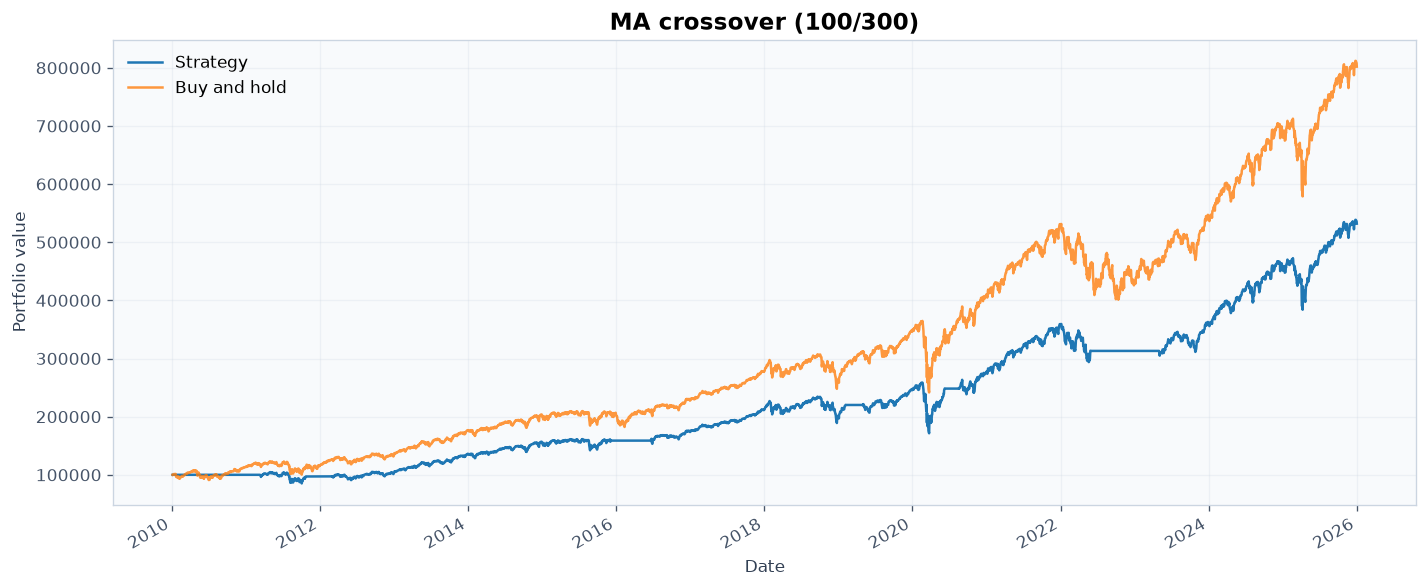

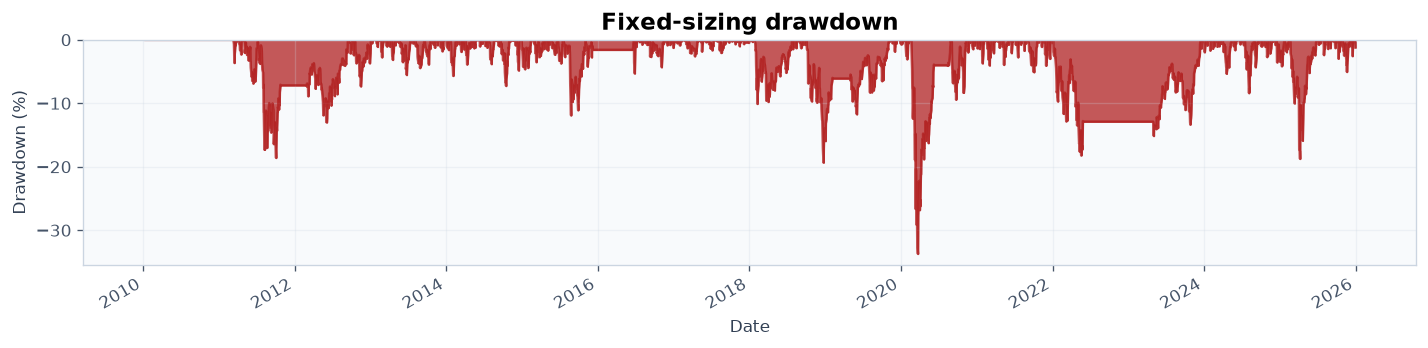

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2010,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
2011,0.00%,0.00%,1.68%,2.90%,-1.12%,-1.69%,-2.00%,-5.50%,-6.94%,10.79%,0.00%,0.00%
2012,0.00%,-0.20%,3.22%,-0.67%,-6.01%,4.06%,1.18%,2.51%,2.54%,-1.82%,0.57%,0.89%
2013,5.12%,1.28%,3.80%,1.92%,2.36%,-1.33%,5.17%,-3.00%,3.16%,4.63%,2.96%,2.59%
2014,-3.52%,4.55%,0.83%,0.70%,2.32%,2.06%,-1.34%,3.95%,-1.38%,2.36%,2.75%,-0.25%
2015,-2.96%,5.62%,-1.57%,0.98%,1.29%,-2.03%,2.26%,-6.10%,-2.55%,8.51%,0.37%,-0.26%
2016,0.00%,0.00%,0.00%,0.00%,0.00%,1.33%,3.65%,0.12%,0.01%,-1.73%,3.68%,2.03%
2017,1.79%,3.93%,0.12%,0.99%,1.41%,0.64%,2.06%,0.29%,2.01%,2.36%,3.06%,1.21%
2018,5.64%,-3.64%,-2.74%,0.52%,2.43%,0.58%,3.70%,3.19%,0.59%,-6.91%,1.85%,-8.80%


In [5]:
plot_equity_curve(fixed_result.frame, title=f'MA crossover ({fast_window}/{slow_window})')
plt.show()
plot_drawdown(fixed_result.frame, title='Fixed-sizing drawdown')
plt.show()
monthly_returns(fixed_result.frame).style.format('{:.2%}', na_rep='')

In [6]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    cost_result = run_backtest(prices['close'], signal, transaction_cost_bps=cost_bps)
    cost_metrics = metrics_for_period(cost_result, splits['test'].index)
    cost_rows.append({
        'cost_bps': cost_bps,
        'test_return': cost_metrics['total_return_after_costs'],
        'test_sharpe': cost_metrics['sharpe_ratio'],
        'test_max_drawdown': cost_metrics['max_drawdown'],
    })

pd.DataFrame(cost_rows).style.format({
    'test_return': '{:.2%}',
    'test_sharpe': '{:.2f}',
    'test_max_drawdown': '{:.2%}',
})

,cost_bps,test_return,test_sharpe,test_max_drawdown
0,0,70.08%,1.26,-18.76%
1,5,69.99%,1.26,-18.76%
2,10,69.91%,1.26,-18.76%
3,25,69.65%,1.25,-18.76%
4,50,69.22%,1.25,-18.76%


## ✅ Conclusion template

Fill this section after running the notebook on the chosen data source:

- Did the crossover beat buy-and-hold after costs in the untouched test period?
- Did volatility targeting improve drawdown or risk-adjusted return, and what did it cost in turnover?
- How sensitive was the conclusion to the cost assumption?
- Which market regimes explain the wins and failures?

A credible result may be that the strategy worked before costs but became unattractive after realistic turnover costs. That is a useful research conclusion, not a failed project.

## ⚖️ What went well / what went wrong

**What went well:** The crossover is easy to explain, uses only past prices, and can reduce exposure during a persistent downtrend. Volatility targeting can further reduce the size of large losses.

**What went wrong:** Moving averages are lagging indicators. The strategy can give back gains before exiting, miss the first part of a rebound, and trade repeatedly in sideways markets. Those whipsaws make transaction costs and window selection important.

Judge it against buy-and-hold using both drawdown and after-cost return; a lower drawdown alone does not prove that the strategy is superior.